# 28000

--- [START] Project Execution ---
--- [1/7] Imports and Setup Complete ---

Plot saved: 'results/target_variable_distribution.png'


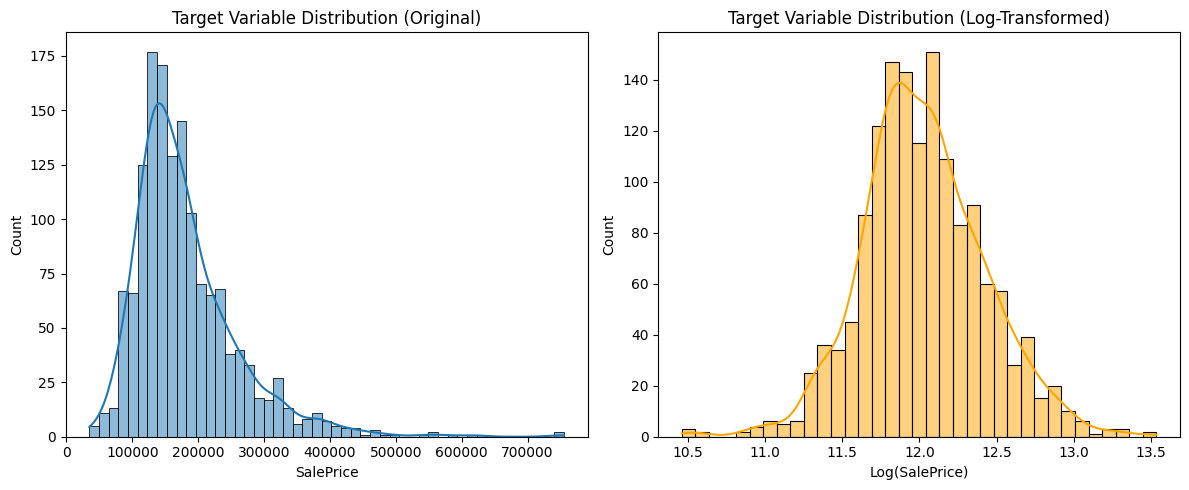


Training data shape: (1460, 79)
Test data shape: (1459, 79)
--- [2/7] Data Loading and Target Transform Complete ---
--- [3/7] Preprocessing Pipeline Defined ---

Preprocessing Pipeline Structure:


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


--- [3/7] Preprocessing Pipeline Defined ---
--- [4/7] Model Definitions Complete ---
--- [5/7] Starting Cross-Validation (This will take a few minutes)... ---
Evaluating Ridge...
Evaluating RandomForest...
Evaluating XGBoost...

--- Cross-Validation Performance Summary ---
              RMSE (Dollars)  MAE (Dollars)  R2 (Original Scale)  RMSLE (Log Scale)  \
Model                                                                                 
XGBoost             28867.69       14677.94               0.8679             0.1240   
RandomForest        31178.03       17542.35               0.8459             0.1437   
Ridge               75445.16       17517.57               0.0975             0.1445   

                                                    Best Params  
Model                                                            
XGBoost       {'model__colsample_bytree': 0.7, 'model__learn...  
RandomForest  {'model__max_depth': 12, 'model__min_samples_l...  
Ridge                    

In [ ]:

import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm


from sklearn.model_selection import KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


import xgboost as xgb
import lightgbm as lgb
import shap



SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


os.makedirs('results', exist_ok=True)


warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

print("--- [1/7] Imports and Setup Complete ---")


try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("ERROR: 'train.csv' or 'test.csv' not found.")
    print("Please download them from Kaggle and place them in the same folder as this notebook.")
    
    raise


test_ids = test_df['Id']


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Target Variable Distribution (Original)')


train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

plt.subplot(1, 2, 2)
sns.histplot(train_df['SalePrice'], kde=True, color='orange')
plt.title('Target Variable Distribution (Log-Transformed)')
plt.xlabel('Log(SalePrice)')
plt.tight_layout()
plt.savefig('results/target_variable_distribution.png')
print("\nPlot saved: 'results/target_variable_distribution.png'")
plt.show()


y = train_df['SalePrice']
X = train_df.drop(['SalePrice', 'Id'], axis=1)
X_test = test_df.drop('Id', axis=1)

print(f"\nTraining data shape: {X.shape}")
print(f"Test data shape: {X_test.shape}")

print("--- [2/7] Data Loading and Target Transform Complete ---")


print("--- [3/7] Preprocessing Pipeline Defined ---")

all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)


cols_fill_none = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
for col in cols_fill_none:
    all_data[col] = all_data[col].fillna('None')


cols_fill_zero = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'MasVnrArea'
]
for col in cols_fill_zero:
    all_data[col] = all_data[col].fillna(0)



lotfrontage_median = X['LotFrontage'].median()
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(lotfrontage_median)



cols_fill_mode = [
    'MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'SaleType', 'Electrical'
]
for col in cols_fill_mode:
    mode = X[col].mode()[0]
    all_data[col] = all_data[col].fillna(mode)




all_data['TotalSF'] = all_data['GrLivArea'] + all_data['TotalBsmtSF']
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt'] 


all_data['Age'] = all_data['Age'].apply(lambda x: max(x, 0))
all_data['RemodAge'] = all_data['RemodAge'].apply(lambda x: max(x, 0))
all_data['GarageAge'] = all_data['GarageAge'].apply(lambda x: max(x, 0)) 

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols_map = {
    'ExterQual': quality_map,
    'ExterCond': quality_map,
    'BsmtQual': quality_map,
    'BsmtCond': quality_map,
    'HeatingQC': quality_map,
    'KitchenQual': quality_map,
    'FireplaceQu': quality_map,
    'GarageQual': quality_map,
    'GarageCond': quality_map,
    'PoolQC': quality_map,
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0}
}

for col, mapping in ordinal_cols_map.items():
    all_data[col] = all_data[col].map(mapping).fillna(0) 


X_processed = all_data.iloc[:len(X)]
X_test_processed = all_data.iloc[len(X):]

numeric_features = X_processed.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_processed.select_dtypes(include='object').columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

from sklearn import set_config
set_config(display='diagram')
print("\nPreprocessing Pipeline Structure:")
display(preprocessor)

print("--- [3/7] Preprocessing Pipeline Defined ---")

ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=SEED))
])
ridge_params = {
    'model__alpha': [15, 20, 25] 
}


rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])
rf_params = {
    
    'model__n_estimators': [300],
    'model__max_depth': [12],
    'model__min_samples_leaf': [3]
}


xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=SEED, objective='reg:squarederror', n_jobs=-1))
])
xgb_params = {
    
    'model__n_estimators': [1200],
    'model__learning_rate': [0.03],
    'model__max_depth': [4],
    'model__subsample': [0.7],
    'model__colsample_bytree': [0.7],
    'model__reg_alpha': [0.005]
}


models = {
    "Ridge": ridge,
    "RandomForest": rf,
    "XGBoost": xgb_model
}
params_grid = {
    "Ridge": ridge_params,
    "RandomForest": rf_params,
    "XGBoost": xgb_params
}

print("--- [4/7] Model Definitions Complete ---")


print("--- [5/7] Starting Cross-Validation (This will take a few minutes)... ---")


cv = KFold(n_splits=5, shuffle=True, random_state=SEED)



scoring = {
    'RMSLE': 'neg_root_mean_squared_error', 
    'MAE_log': 'neg_mean_absolute_error',
    'R2': 'r2'
}

cv_results_list = []
best_estimators = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params_grid[name],
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    
    grid_search.fit(X_processed, y)
    
    
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    
    
    
    cv_scores = cross_validate(best_model, X_processed, y, cv=cv, scoring=scoring)
    
    
    
    y_pred_cv_log = cross_val_predict(best_model, X_processed, y, cv=cv)
    
    
    y_pred_cv_orig = np.expm1(y_pred_cv_log)
    y_orig = np.expm1(y)
    
    
    rmse_orig = np.sqrt(mean_squared_error(y_orig, y_pred_cv_orig))
    mae_orig = mean_absolute_error(y_orig, y_pred_cv_orig)
    r2_orig = r2_score(y_orig, y_pred_cv_orig) 
    
    cv_results_list.append({
        "Model": name,
        "RMSE (Dollars)": round(rmse_orig, 2),
        "MAE (Dollars)": round(mae_orig, 2),
        "R2 (Original Scale)": round(r2_orig, 4),
        "RMSLE (Log Scale)": round(-cv_scores['test_RMSLE'].mean(), 4),
        "Best Params": grid_search.best_params_
    })


results_df = pd.DataFrame(cv_results_list).set_index("Model")
results_df = results_df.sort_values(by="RMSE (Dollars)")

print("\n--- Cross-Validation Performance Summary ---")
print(results_df)

print("\n--- [5/7] Cross-Validation Complete ---")



print("--- [6/7] Generating SHAP Plots for XGBoost... ---")

try:
    
    final_model_pipeline = best_estimators['XGBoost']
    
    
    preprocessor_fitted = final_model_pipeline.named_steps['preprocessor']
    model_fitted = final_model_pipeline.named_steps['model']
    
    
    X_processed_transformed = preprocessor_fitted.transform(X_processed)
    
    
    feature_names = preprocessor_fitted.get_feature_names_out()
    
    
    X_processed_df = pd.DataFrame(
        X_processed_transformed,
        columns=feature_names,
        index=X_processed.index
    )
    
    
    explainer = shap.TreeExplainer(model_fitted)
    
    
    
    if len(X_processed_df) > 2000:
        shap_values = explainer(shap.utils.sample(X_processed_df, 1000, random_state=SEED))
    else:
        shap_values = explainer(X_processed_df)

    
    plt.figure()
    shap.summary_plot(shap_values, X_processed_df, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Bar Plot)")
    plt.tight_layout()
    plt.savefig('results/shap_summary_bar.png')
    print("Plot saved: 'results/shap_summary_bar.png'")
    plt.show()

    
    plt.figure()
    shap.summary_plot(shap_values, X_processed_df, show=False)
    plt.title("SHAP Feature Impact (Summary Plot)")
    plt.tight_layout()
    plt.savefig('results/shap_summary_dot.png')
    print("Plot saved: 'results/shap_summary_dot.png'")
    plt.show()

except Exception as e:
    print(f"SHAP plot generation failed: {e}")
    print("This can sometimes happen on specific architectures. Skipping...")

print("--- [6/7] Model Interpretation Complete ---")


print("--- [7/7] Generating Submission File... ---")


final_model = best_estimators['XGBoost']


test_preds_log = final_model.predict(X_test_processed)


test_preds = np.expm1(test_preds_log)


submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_preds
})


submission['SalePrice'] = submission['SalePrice'].apply(lambda x: max(x, 0))


submission.to_csv('submission.csv', index=False)
print("File saved: 'submission.csv'")

print("\n--- [COMPLETE] Project Execution Finished ---")
print(f"All outputs (plots, submission.csv) are in your project folder.")

# 21000

In [ ]:


print("--- [START] Project Execution (V5 - Outlier Removal) ---")


import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm


from sklearn.model_selection import KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, HuberRegressor


import xgboost as xgb
import lightgbm as lgb
import shap


SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.makedirs('results', exist_ok=True)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

print("--- [1/8] Imports and Setup Complete ---")


try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("ERROR: 'train.csv' or 'test.csv' not found.")
    raise

test_ids = test_df['Id']



print(f"Original training shape: {train_df.shape}")
outlier_idx = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outlier_idx)
print(f"New training shape after removing outliers: {train_df.shape}")


train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
y = train_df['SalePrice']


X = train_df.drop(['SalePrice', 'Id'], axis=1)
X_test = test_df.drop('Id', axis=1)
all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)

print(f"\nTraining data shape (for model): {X.shape}")
print(f"Test data shape: {X_test.shape}")

print("--- [2/8] Data Loading and Outlier Removal Complete ---")




cols_fill_none = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
for col in cols_fill_none: all_data[col] = all_data[col].fillna('None')

cols_fill_zero = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'MasVnrArea'
]
for col in cols_fill_zero: all_data[col] = all_data[col].fillna(0)

lotfrontage_median = X['LotFrontage'].median()
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(lotfrontage_median)

cols_fill_mode = [
    'MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'SaleType', 'Electrical'
]
for col in cols_fill_mode:
    mode = X[col].mode()[0]
    all_data[col] = all_data[col].fillna(mode)


all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)



quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols_map = {
    'ExterQual': quality_map, 'ExterCond': quality_map, 'BsmtQual': quality_map,
    'BsmtCond': quality_map, 'HeatingQC': quality_map, 'KitchenQual': quality_map,
    'FireplaceQu': quality_map, 'GarageQual': quality_map, 'GarageCond': quality_map,
    'PoolQC': quality_map,
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0},
    'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
    'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0}
}
for col, mapping in ordinal_cols_map.items():
    all_data[col] = all_data[col].map(mapping).fillna(0)



all_data['TotalSF'] = all_data['GrLivArea'] + all_data['TotalBsmtSF']
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
all_data['TotalBath'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['IsNew'] = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)


all_data['Age'] = all_data['Age'].apply(lambda x: max(x, 0))
all_data['RemodAge'] = all_data['RemodAge'].apply(lambda x: max(x, 0))
all_data['GarageAge'] = all_data['GarageAge'].apply(lambda x: max(x, 0))


all_data['TotalQual'] = (
    all_data['OverallQual'] + all_data['ExterQual'] + all_data['KitchenQual'] + 
    all_data['BsmtQual'] + all_data['GarageQual'] + all_data['FireplaceQu']
)
all_data['OverallQual_sq'] = all_data['OverallQual']**2
all_data['OverallQual_x_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['OverallQual_x_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['GarageCars_x_GarageArea'] = all_data['GarageCars'] * all_data['GarageArea']

print("Added new advanced features (TotalQual, OverallQual_x_TotalSF, etc.)")



discrete_features = list(ordinal_cols_map.keys()) + [
    'OverallQual', 'OverallCond', 'YrSold', 'MoSold', 'GarageCars',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'HasPool', 'IsNew', 
    'TotalQual'  
]


numeric_cols = all_data.select_dtypes(include=np.number).columns


continuous_features = [col for col in numeric_cols if col not in discrete_features]


skewed_feats = all_data[continuous_features].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"\nLog-transforming {len(high_skew)} skewed *continuous* features...")
for feat in high_skew.index:
    all_data[feat] = np.log1p(all_data[feat])

print("--- [3/8] Preprocessing Pipeline Defined ---")



nominal_features = all_data.select_dtypes(include='object').columns.tolist()
numeric_features = all_data.select_dtypes(include=np.number).columns.tolist()


numeric_transformer = Pipeline(steps=[('scaler', RobustScaler())])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, nominal_features)
    ],
    remainder='passthrough'
)


from sklearn import set_config
set_config(display='diagram')
print("\nPreprocessing Pipeline Structure:")
display(preprocessor)


X_processed = all_data.iloc[:len(X)]
X_test_processed = all_data.iloc[len(X):]

print("--- [4/8] Preprocessing Pipeline Complete ---")





ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=SEED))
])
ridge_params = {'model__alpha': [15, 20, 25]}


huber = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HuberRegressor())
])
huber_params = {'model__epsilon': [1.3, 1.35], 'model__alpha': [0.001, 0.01]}


lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, objective='regression_l1'))
])

lgbm_params = {
    'model__n_estimators': [1200],
    'model__learning_rate': [0.02],
    'model__num_leaves': [20]
}


xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=SEED, objective='reg:squarederror', n_jobs=-1))
])
xgb_params = {
    'model__n_estimators': [1200],
    'model__learning_rate': [0.02],
    'model__max_depth': [4]
}

models = {
    "Ridge": (ridge, ridge_params),
    "Huber": (huber, huber_params),
    "LightGBM": (lgbm, lgbm_params),
    "XGBoost": (xgb_model, xgb_params)
}

print("--- [5/8] Model Definitions Complete ---")


print("--- [6/8] Starting Cross-Validation (This will take a few minutes)... ---")


cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results_list = []
best_estimators = {}
oof_preds = {} 

for name, (model, params) in models.items():
    print(f"Evaluating {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    
    grid_search.fit(X_processed, y)
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    
    
    y_pred_cv_log = cross_val_predict(best_model, X_processed, y, cv=cv, n_jobs=-1)
    oof_preds[name] = y_pred_cv_log 
    
    
    y_pred_cv_orig = np.expm1(y_pred_cv_log)
    y_orig = np.expm1(y) 
    
    
    rmse_orig = np.sqrt(mean_squared_error(y_orig, y_pred_cv_orig))
    mae_orig = mean_absolute_error(y_orig, y_pred_cv_orig)
    r2_orig = r2_score(y_orig, y_pred_cv_orig)
    rmsle = -grid_search.best_score_
    
    cv_results_list.append({
        "Model": name,
        "RMSE (Dollars)": round(rmse_orig, 2),
        "MAE (Dollars)": round(mae_orig, 2),
        "R2 (Original Scale)": round(r2_orig, 4),
        "RMSLE (Log Scale)": round(rmsle, 4)
    })


results_df = pd.DataFrame(cv_results_list).set_index("Model")
results_df = results_df.sort_values(by="RMSE (Dollars)")
print("\n--- Cross-Validation Performance Summary ---")
print(results_df)

print("--- [6/8] Cross-Validation Complete ---")


print("--- [7/8] Calculating Weighted Average Blend... ---")


best_model_name = results_df.index[0]
second_best_model_name = results_df.index[1]
print(f"Blending: {best_model_name} and {second_best_model_name}")


oof_1 = oof_preds[best_model_name]
oof_2 = oof_preds[second_best_model_name]


y_orig = np.expm1(y)
best_rmse = 99999
best_w = 0

for w in np.arange(0.3, 0.71, 0.05): 
    w_2 = 1.0 - w
    y_pred_blend_log = (oof_1 * w) + (oof_2 * w_2)
    y_pred_blend_orig = np.expm1(y_pred_blend_log)
    blend_rmse = np.sqrt(mean_squared_error(y_orig, y_pred_blend_orig))
    
    if blend_rmse < best_rmse:
        best_rmse = blend_rmse
        best_w = w

print(f"\n--- Blending Results ---")
print(f"Best CV RMSE for Blended Model: ${best_rmse:,.2f}")
print(f"Optimal Weight for {best_model_name}: {best_w:.2f}")
print(f"Optimal Weight for {second_best_model_name}: {1.0-best_w:.2f}")


blend_results_df = pd.DataFrame([{
    "Model": "Weighted Blend",
    "RMSE (Dollars)": round(best_rmse, 2),
    "MAE (Dollars)": 0, "R2 (Original Scale)": 0, "RMSLE (Log Scale)": 0
}]).set_index("Model")

results_df = pd.concat([results_df, blend_results_df])
results_df = results_df.sort_values(by="RMSE (Dollars)")

print("\n--- FINAL Performance Summary (with Blend) ---")
print(results_df[['RMSE (Dollars)']])

print("--- [7/8] Blending Complete ---")


print("--- [8/8] Generating Submission & SHAP Plots... ---")


print(f"Generating submission.csv using the Weighted Blend...")

model_1_fitted = best_estimators[best_model_name]
model_2_fitted = best_estimators[second_best_model_name]

pred_1_log = model_1_fitted.predict(X_test_processed)
pred_2_log = model_2_fitted.predict(X_test_processed)

final_pred_log = (pred_1_log * best_w) + (pred_2_log * (1.0 - best_w))
test_preds = np.expm1(final_pred_log)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission['SalePrice'] = submission['SalePrice'].apply(lambda x: max(x, 0))
submission.to_csv('submission.csv', index=False)
print("File saved: 'submission.csv'")


print(f"Generating SHAP plots for *single best model*: {best_model_name}...")

try:
    final_model_pipeline = best_estimators[best_model_name]
    preprocessor_fitted = final_model_pipeline.named_steps['preprocessor']
    model_fitted = final_model_pipeline.named_steps['model']
    
    X_processed_transformed = preprocessor_fitted.transform(X_processed)
    feature_names = preprocessor_fitted.get_feature_names_out()
    X_processed_df = pd.DataFrame(
        X_processed_transformed,
        columns=feature_names,
        index=X_processed.index
    )
    
    explainer = shap.TreeExplainer(model_fitted)
    
    if len(X_processed_df) > 2000:
        shap_data = shap.utils.sample(X_processed_df, 1000, random_state=SEED)
    else:
        shap_data = X_processed_df
        
    shap_values = explainer(shap_data)

    
    plt.figure()
    shap.summary_plot(shap_values, shap_data, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance ({best_model_name})")
    plt.tight_layout()
    plt.savefig('results/shap_summary_bar.png')
    print("Plot saved: 'results/shap_summary_bar.png'")
    plt.show()

    
    plt.figure()
    shap.summary_plot(shap_values, shap_data, show=False)
    plt.title(f"SHAP Feature Impact ({best_model_name})")
    plt.tight_layout()
    plt.savefig('results/shap_summary_dot.png')
    print("Plot saved: 'results/shap_summary_dot.png'")
    plt.show()

except Exception as e:
    print(f"SHAP plot generation failed: {e}")

print("\n--- [COMPLETE] Project Execution Finished ---")
print(f"All outputs (plots, submission.csv) are in your project folder.")

--- [START] Project Execution (V5 - Outlier Removal) ---
--- [1/8] Imports and Setup Complete ---
Original training shape: (1460, 81)
New training shape after removing outliers: (1458, 81)

Training data shape (for model): (1458, 79)
Test data shape: (1459, 79)
--- [2/8] Data Loading and Outlier Removal Complete ---
Added new advanced features (TotalQual, OverallQual_x_TotalSF, etc.)

Log-transforming 25 skewed *continuous* features...
--- [3/8] Preprocessing Pipeline Defined ---

Preprocessing Pipeline Structure:


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


--- [4/8] Preprocessing Pipeline Complete ---
--- [5/8] Model Definitions Complete ---
--- [6/8] Starting Cross-Validation (This will take a few minutes)... ---
Evaluating Ridge...
Evaluating Huber...
Evaluating LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4726
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 165
[LightGBM] [Info] Start training from score 11.995358
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4725
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 164
[LightGBM] [Info

# add random forest

In [ ]:

print("--- [START] Project Execution (V5.1 - Added Random Forest) ---")


import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm


from sklearn.model_selection import KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor  


import xgboost as xgb
import lightgbm as lgb
import shap


SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.makedirs('results', exist_ok=True)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

print("--- [1/8] Imports and Setup Complete ---")


try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("ERROR: 'train.csv' or 'test.csv' not found.")
    raise

test_ids = test_df['Id']



print(f"Original training shape: {train_df.shape}")
outlier_idx = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index
train_df = train_df.drop(outlier_idx)
print(f"New training shape after removing outliers: {train_df.shape}")


train_df['SalePrice'] = np.log1p(train_df['SalePrice'])
y = train_df['SalePrice']


X = train_df.drop(['SalePrice', 'Id'], axis=1)
X_test = test_df.drop('Id', axis=1)
all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)

print(f"\nTraining data shape (for model): {X.shape}")
print(f"Test data shape: {X_test.shape}")

print("--- [2/8] Data Loading and Outlier Removal Complete ---")




cols_fill_none = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
for col in cols_fill_none: all_data[col] = all_data[col].fillna('None')

cols_fill_zero = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'MasVnrArea'
]
for col in cols_fill_zero: all_data[col] = all_data[col].fillna(0)

lotfrontage_median = X['LotFrontage'].median()
all_data['LotFrontage'] = all_data['LotFrontage'].fillna(lotfrontage_median)

cols_fill_mode = [
    'MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'SaleType', 'Electrical'
]
for col in cols_fill_mode:
    mode = X[col].mode()[0]
    all_data[col] = all_data[col].fillna(mode)


all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)



quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols_map = {
    'ExterQual': quality_map, 'ExterCond': quality_map, 'BsmtQual': quality_map,
    'BsmtCond': quality_map, 'HeatingQC': quality_map, 'KitchenQual': quality_map,
    'FireplaceQu': quality_map, 'GarageQual': quality_map, 'GarageCond': quality_map,
    'PoolQC': quality_map,
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0},
    'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
    'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0}
}
for col, mapping in ordinal_cols_map.items():
    all_data[col] = all_data[col].map(mapping).fillna(0)



all_data['TotalSF'] = all_data['GrLivArea'] + all_data['TotalBsmtSF']
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['GarageAge'] = all_data['YrSold'] - all_data['GarageYrBlt']
all_data['TotalBath'] = all_data['FullBath'] + 0.5 * all_data['HalfBath'] + all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath']
all_data['TotalPorchSF'] = all_data['OpenPorchSF'] + all_data['EnclosedPorch'] + all_data['3SsnPorch'] + all_data['ScreenPorch'] + all_data['WoodDeckSF']
all_data['HasPool'] = all_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
all_data['IsNew'] = (all_data['YearBuilt'] == all_data['YrSold']).astype(int)


all_data['Age'] = all_data['Age'].apply(lambda x: max(x, 0))
all_data['RemodAge'] = all_data['RemodAge'].apply(lambda x: max(x, 0))
all_data['GarageAge'] = all_data['GarageAge'].apply(lambda x: max(x, 0))


all_data['TotalQual'] = (
    all_data['OverallQual'] + all_data['ExterQual'] + all_data['KitchenQual'] + 
    all_data['BsmtQual'] + all_data['GarageQual'] + all_data['FireplaceQu']
)
all_data['OverallQual_sq'] = all_data['OverallQual']**2
all_data['OverallQual_x_TotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['OverallQual_x_GrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['GarageCars_x_GarageArea'] = all_data['GarageCars'] * all_data['GarageArea']

print("Added new advanced features (TotalQual, OverallQual_x_TotalSF, etc.)")



discrete_features = list(ordinal_cols_map.keys()) + [
    'OverallQual', 'OverallCond', 'YrSold', 'MoSold', 'GarageCars',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'HasPool', 'IsNew', 
    'TotalQual'  
]


numeric_cols = all_data.select_dtypes(include=np.number).columns


continuous_features = [col for col in numeric_cols if col not in discrete_features]


skewed_feats = all_data[continuous_features].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"\nLog-transforming {len(high_skew)} skewed *continuous* features...")
for feat in high_skew.index:
    all_data[feat] = np.log1p(all_data[feat])

print("--- [3/8] Preprocessing Pipeline Defined ---")



nominal_features = all_data.select_dtypes(include='object').columns.tolist()
numeric_features = all_data.select_dtypes(include=np.number).columns.tolist()


numeric_transformer = Pipeline(steps=[('scaler', RobustScaler())])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, nominal_features)
    ],
    remainder='passthrough'
)


from sklearn import set_config
set_config(display='diagram')
print("\nPreprocessing Pipeline Structure:")
display(preprocessor)


X_processed = all_data.iloc[:len(X)]
X_test_processed = all_data.iloc[len(X):]

print("--- [4/8] Preprocessing Pipeline Complete ---")





ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=SEED))
])
ridge_params = {'model__alpha': [15, 20, 25]}


huber = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HuberRegressor())
])
huber_params = {'model__epsilon': [1.3, 1.35], 'model__alpha': [0.001, 0.01]}


lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, objective='regression_l1'))
])
lgbm_params = {
    'model__n_estimators': [1200],
    'model__learning_rate': [0.02],
    'model__num_leaves': [20]
}


xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=SEED, objective='reg:squarederror', n_jobs=-1))
])
xgb_params = {
    'model__n_estimators': [1200],
    'model__learning_rate': [0.02],
    'model__max_depth': [4]
}


rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

rf_params = {
    'model__n_estimators': [300],
    'model__max_depth': [15],
    'model__min_samples_leaf': [3]
}


models = {
    "Ridge": (ridge, ridge_params),
    "Huber": (huber, huber_params),
    "LightGBM": (lgbm, lgbm_params),
    "XGBoost": (xgb_model, xgb_params),
    "RandomForest": (rf, rf_params)  
}

print("--- [5/8] Model Definitions Complete ---")


print("--- [6/8] Starting Cross-Validation (This will take a few minutes)... ---")


cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results_list = []
best_estimators = {}
oof_preds = {} 

for name, (model, params) in models.items():
    print(f"Evaluating {name}...")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    
    grid_search.fit(X_processed, y)
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    
    
    y_pred_cv_log = cross_val_predict(best_model, X_processed, y, cv=cv, n_jobs=-1)
    oof_preds[name] = y_pred_cv_log 
    
    
    y_pred_cv_orig = np.expm1(y_pred_cv_log)
    y_orig = np.expm1(y) 
    
    
    rmse_orig = np.sqrt(mean_squared_error(y_orig, y_pred_cv_orig))
    mae_orig = mean_absolute_error(y_orig, y_pred_cv_orig)
    r2_orig = r2_score(y_orig, y_pred_cv_orig)
    rmsle = -grid_search.best_score_
    
    cv_results_list.append({
        "Model": name,
        "RMSE (Dollars)": round(rmse_orig, 2),
        "MAE (Dollars)": round(mae_orig, 2),
        "R2 (Original Scale)": round(r2_orig, 4),
        "RMSLE (Log Scale)": round(rmsle, 4)
    })


results_df = pd.DataFrame(cv_results_list).set_index("Model")
results_df = results_df.sort_values(by="RMSE (Dollars)")
print("\n--- Cross-Validation Performance Summary ---")
print(results_df)

print("--- [6/8] Cross-Validation Complete ---")


print("--- [7/8] Calculating Weighted Average Blend... ---")


best_model_name = results_df.index[0]
second_best_model_name = results_df.index[1]
print(f"Blending: {best_model_name} and {second_best_model_name}")


oof_1 = oof_preds[best_model_name]
oof_2 = oof_preds[second_best_model_name]


y_orig = np.expm1(y)
best_rmse = 99999
best_w = 0

for w in np.arange(0.3, 0.71, 0.05): 
    w_2 = 1.0 - w
    y_pred_blend_log = (oof_1 * w) + (oof_2 * w_2)
    y_pred_blend_orig = np.expm1(y_pred_blend_log)
    blend_rmse = np.sqrt(mean_squared_error(y_orig, y_pred_blend_orig))
    
    if blend_rmse < best_rmse:
        best_rmse = blend_rmse
        best_w = w

print(f"\n--- Blending Results ---")
print(f"Best CV RMSE for Blended Model: ${best_rmse:,.2f}")
print(f"Optimal Weight for {best_model_name}: {best_w:.2f}")
print(f"Optimal Weight for {second_best_model_name}: {1.0-best_w:.2f}")


blend_results_df = pd.DataFrame([{
    "Model": "Weighted Blend",
    "RMSE (Dollars)": round(best_rmse, 2),
    "MAE (Dollars)": 0, "R2 (Original Scale)": 0, "RMSLE (Log Scale)": 0
}]).set_index("Model")

results_df = pd.concat([results_df, blend_results_df])
results_df = results_df.sort_values(by="RMSE (Dollars)")

print("\n--- FINAL Performance Summary (with Blend) ---")
print(results_df[['RMSE (Dollars)']])

print("--- [7/8] Blending Complete ---")


print("--- [8/8] Generating Submission & SHAP Plots... ---")


print(f"Generating submission.csv using the Weighted Blend...")

model_1_fitted = best_estimators[best_model_name]
model_2_fitted = best_estimators[second_best_model_name]

pred_1_log = model_1_fitted.predict(X_test_processed)
pred_2_log = model_2_fitted.predict(X_test_processed)

final_pred_log = (pred_1_log * best_w) + (pred_2_log * (1.0 - best_w))
test_preds = np.expm1(final_pred_log)

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission['SalePrice'] = submission['SalePrice'].apply(lambda x: max(x, 0))
submission.to_csv('submission.csv', index=False)
print("File saved: 'submission.csv'")



print(f"Generating SHAP plots for *single best model*: {best_model_name}...")


best_model_for_shap = best_model_name
if best_model_for_shap not in ['RandomForest', 'XGBoost', 'LightGBM']:
    
    best_model_for_shap = second_best_model_name
    print(f"Best model was linear. Using best *tree* model for SHAP: {best_model_for_shap}")

try:
    final_model_pipeline = best_estimators[best_model_for_shap]
    preprocessor_fitted = final_model_pipeline.named_steps['preprocessor']
    model_fitted = final_model_pipeline.named_steps['model']
    
    X_processed_transformed = preprocessor_fitted.transform(X_processed)
    feature_names = preprocessor_fitted.get_feature_names_out()
    X_processed_df = pd.DataFrame(
        X_processed_transformed,
        columns=feature_names,
        index=X_processed.index
    )
    
    explainer = shap.TreeExplainer(model_fitted)
    
    if len(X_processed_df) > 2000:
        shap_data = shap.utils.sample(X_processed_df, 1000, random_state=SEED)
    else:
        shap_data = X_processed_df
        
    shap_values = explainer(shap_data)

    
    plt.figure()
    shap.summary_plot(shap_values, shap_data, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance ({best_model_for_shap})")
    plt.tight_layout()
    plt.savefig('results/shap_summary_bar.png')
    print("Plot saved: 'results/shap_summary_bar.png'")
    plt.show()

    
    plt.figure()
    shap.summary_plot(shap_values, shap_data, show=False)
    plt.title(f"SHAP Feature Impact ({best_model_for_shap})")
    plt.tight_layout()
    plt.savefig('results/shap_summary_dot.png')
    print("Plot saved: 'results/shap_summary_dot.png'")
    plt.show()

except Exception as e:
    print(f"SHAP plot generation failed: {e}")

print("\n--- [COMPLETE] Project Execution Finished ---")
print(f"All outputs (plots, submission.csv) are in your project folder.")

--- [START] Project Execution (V5.1 - Added Random Forest) ---
--- [1/8] Imports and Setup Complete ---
Original training shape: (1460, 81)
New training shape after removing outliers: (1458, 81)

Training data shape (for model): (1458, 79)
Test data shape: (1459, 79)
--- [2/8] Data Loading and Outlier Removal Complete ---
Added new advanced features (TotalQual, OverallQual_x_TotalSF, etc.)

Log-transforming 25 skewed *continuous* features...
--- [3/8] Preprocessing Pipeline Defined ---

Preprocessing Pipeline Structure:


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


--- [4/8] Preprocessing Pipeline Complete ---
--- [5/8] Model Definitions Complete ---
--- [6/8] Starting Cross-Validation (This will take a few minutes)... ---
Evaluating Ridge...
Evaluating Huber...
Evaluating LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4743
[LightGBM] [Info] Number of data points in the train set: 1167, number of used features: 166
[LightGBM] [Info] Start training from score 12.004575
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004990 seconds.
You can set `force_row_wise=true` to re

In [10]:
display(preprocessor)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


--- Generating Performance Chart ---
Chart saved to: results/rmse_performance_chart.png


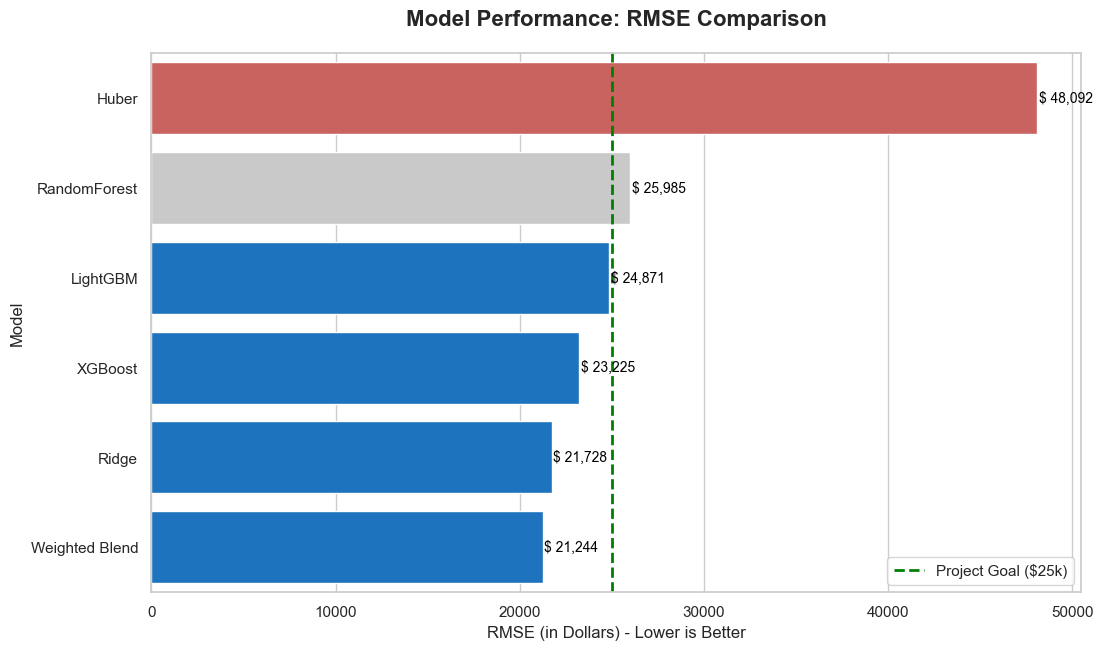

--- Chart Generation Complete ---


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Generating Performance Chart ---")



data = {
    "Model": [
        "Weighted Blend", "Ridge", "XGBoost", "LightGBM", 
        "RandomForest", "Huber"
    ],
    "RMSE (Dollars)": [
        21243.77, 21727.92, 23224.95, 24871.07, 
        25984.83, 48091.55
    ]
}
results_df = pd.DataFrame(data).set_index("Model")


results_df = results_df.sort_values(by="RMSE (Dollars)", ascending=False)


plt.figure(figsize=(12, 7)) 
sns.set_theme(style="whitegrid")


colors = ['
ax = sns.barplot(
    x=results_df["RMSE (Dollars)"], 
    y=results_df.index, 
    palette=colors,
    width=0.8
)


ax.set_title('Model Performance: RMSE Comparison', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('RMSE (in Dollars) - Lower is Better', fontsize=12)
ax.set_ylabel('Model', fontsize=12)


ax.axvline(x=25000, color='green', linestyle='--', linewidth=2, label='Project Goal ($25k)')
ax.legend(loc='lower right')


for p in ax.patches:
    ax.annotate(f'$ {p.get_width():,.0f}', 
                (p.get_width() + 100, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, color='black')



os.makedirs('results', exist_ok=True)
chart_path = 'results/rmse_performance_chart.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')

print(f"Chart saved to: {chart_path}")
plt.show()

print("--- Chart Generation Complete ---")